# 4.4 模型选择、欠拟合和过拟合

机器学习不仅要降低训练误差，更要在未见过的数据上保持良好表现。本节用多项式回归观察模型容量不足、合适和过强时的差异。

原教材：[4.4 模型选择、欠拟合和过拟合](https://zh.d2l.ai/chapter_multilayer-perceptrons/underfit-overfit.html)

> 本章代码只使用 PyTorch、Matplotlib 等基础库，不依赖 `d2l`。

## 学习目标

1. 区分训练集、验证集和测试集的职责；
2. 理解训练误差与泛化误差；
3. 根据训练/验证曲线判断欠拟合和过拟合；
4. 理解模型容量、数据量和正则化之间的关系。

## 4.4.1 训练误差与泛化误差

训练误差是在参与参数学习的数据上得到的误差；泛化误差是模型对同一总体分布中新样本的期望误差，实际只能用独立测试集近似估计。

验证集用于选择模型结构和超参数，测试集只应在最终方案确定后使用。若反复根据测试结果调参，测试集也会被间接拟合，评估将不再客观。

| 数据划分 | 是否更新参数 | 主要用途 |
|---|---:|---|
| 训练集 | 是 | 学习权重和偏置 |
| 验证集 | 否 | 选择模型与超参数 |
| 测试集 | 否 | 最终一次评估泛化能力 |

In [1]:
from pathlib import Path  # 统一管理本地和 Google Drive 中的图片路径

import matplotlib.pyplot as plt  # 绘制数据、拟合曲线和损失曲线
import torch  # 提供张量计算、自动微分与优化器
from torch import nn  # 提供网络层、损失函数和 Sequential 容器

try:  # 尝试判断当前环境是否为 Google Colab
    from google.colab import drive  # 导入 Colab 的云盘挂载工具
    drive.mount('/content/drive')  # 挂载用户的“我的云端硬盘”
    project_root = Path('/content/drive/MyDrive/d2l_learning')  # 指向云盘中的项目根目录
except ImportError:  # 本地环境没有 google.colab 时进入此分支
    project_root = Path.cwd().parent if Path.cwd().name == 'Chapter_4' else Path.cwd()  # 推断本地项目根目录

figure_dir = project_root / 'Chapter_4' / 'images'  # 设置第 4 章图片目录
figure_dir.mkdir(parents=True, exist_ok=True)  # 创建目录且允许目录已经存在
torch.manual_seed(42)  # 固定 CPU 随机种子以复现实验结果
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))  # 优先选择 CUDA，其次选择 MPS，最后使用 CPU
print('计算设备:', device)  # 输出实际采用的训练设备

Mounted at /content/drive
计算设备: cpu


## 4.4.2 多项式回归实验

真实关系设为三次多项式：

$$y=5+1.2x-3.4x^2+5.6x^3+\epsilon,$$

其中 $\epsilon$ 是随机噪声。我们分别使用 1 次、3 次和 15 次多项式拟合。输入特征采用 $x^i/i!$，这样高次项的数值不会增长得过快。

In [2]:
num_train, num_val, max_degree = 10, 30, 20  # 使用较少训练样本和较多验证样本以清晰观察过拟合
true_w = torch.zeros(max_degree, device=device)  # 在计算设备上创建保存真实系数的零向量
true_w[:4] = torch.tensor([5.0, 1.2, -3.4, 5.6], device=device)  # 在计算设备上写入常数项到三次项的真实系数
features = torch.randn(num_train + num_val, 1, device=device)  # 在计算设备上采样原始输入 x
powers = torch.arange(max_degree, device=device).reshape(1, -1)  # 在计算设备上生成从 0 到 19 次的指数
factorials = torch.exp(torch.lgamma(torch.arange(1, max_degree + 1, dtype=torch.float32, device=device)))  # 在计算设备上计算 0! 到 19!
poly_features = features.pow(powers) / factorials  # 构造每个样本的 x^i/i! 多项式特征
labels = poly_features @ true_w  # 根据真实系数计算无噪声标签
labels += torch.randn_like(labels) * 0.2  # 加入标准差为 0.2 的高斯观测噪声
train_features = poly_features[:num_train]  # 取前 10 个样本作为训练特征
val_features = poly_features[num_train:]  # 取后 30 个样本作为验证特征
train_labels = labels[:num_train].reshape(-1, 1)  # 将训练标签整理为 [10,1]
val_labels = labels[num_train:].reshape(-1, 1)  # 将验证标签整理为 [30,1]
print('训练特征形状:', train_features.shape)  # 检查训练特征是否为 [10,20]
print('验证特征形状:', val_features.shape)  # 检查验证特征是否为 [30,20]

训练特征形状: torch.Size([10, 20])
验证特征形状: torch.Size([30, 20])


In [3]:
def train_polynomial(degree, num_epochs=3000, learning_rate=0.03):  # 充分训练指定次数的多项式模型以便比较容量
    num_features = degree + 1  # 常数项到 degree 次项共需要 degree+1 个特征
    model = nn.Linear(num_features, 1, bias=False).to(device)  # 创建线性模型并将参数移动到计算设备
    nn.init.normal_(model.weight, mean=0.0, std=0.01)  # 用小随机数初始化模型权重
    loss_fn = nn.MSELoss()  # 创建均方误差损失函数
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  # 创建收敛较稳定的 Adam 优化器
    history = {'train': [], 'val': []}  # 创建保存训练损失和验证损失的字典
    for epoch in range(num_epochs):  # 按指定轮数重复训练
        model.train()  # 将模型切换为训练模式
        optimizer.zero_grad()  # 清除上一轮保留在参数上的梯度
        predictions = model(train_features[:, :num_features])  # 使用常数项到 degree 次项进行前向传播
        loss = loss_fn(predictions, train_labels)  # 计算训练预测与真实标签的均方误差
        loss.backward()  # 反向传播并计算模型参数的梯度
        optimizer.step()  # 根据梯度更新模型权重
        model.eval()  # 将模型切换为评估模式
        with torch.no_grad():  # 评估时关闭梯度记录以节省资源
            train_loss = loss_fn(model(train_features[:, :num_features]), train_labels).item()  # 计算更新后的训练损失
            val_loss = loss_fn(model(val_features[:, :num_features]), val_labels).item()  # 计算独立验证集损失
        history['train'].append(train_loss)  # 记录当前轮训练损失
        history['val'].append(val_loss)  # 记录当前轮验证损失
    return model, history  # 返回训练完成的模型及完整损失历史

degrees = [1, 3, 15]  # 分别选择容量不足、合适和容量较强的模型
results = {}  # 创建保存三个实验结果的字典
for degree in degrees:  # 逐个训练不同次数的多项式模型
    results[degree] = train_polynomial(degree)  # 以次数为键保存模型和损失历史
    current_history = results[degree][1]  # 取出当前模型的损失历史
    print(f'{degree:2d} 次: 训练损失 {current_history["train"][-1]:.4f}, 验证损失 {current_history["val"][-1]:.4f}')  # 输出最终指标

 1 次: 训练损失 9.3684, 验证损失 8.3449
 3 次: 训练损失 0.0216, 验证损失 0.0523
15 次: 训练损失 0.0210, 验证损失 0.0618


图片已保存到：/content/drive/MyDrive/d2l_learning/Chapter_4/images/4.4_model_selection.png


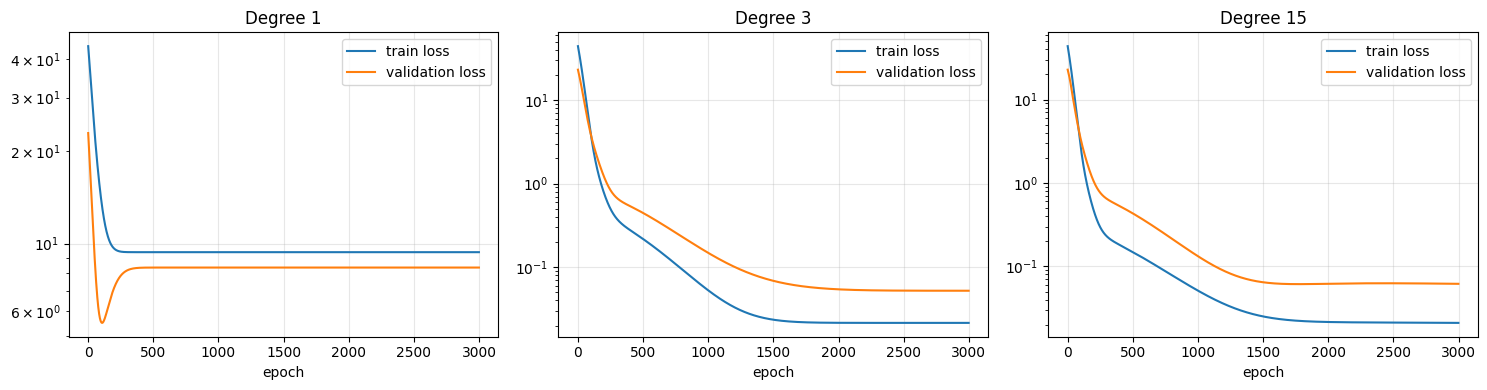

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 创建一行三列的损失曲线画布
for axis, degree in zip(axes, degrees):  # 为每个模型次数选择一个坐标轴
    history = results[degree][1]  # 取出当前次数模型的训练历史
    axis.semilogy(history['train'], label='train loss')  # 用对数纵轴绘制训练损失
    axis.semilogy(history['val'], label='validation loss')  # 用对数纵轴绘制验证损失
    axis.set_title(f'Degree {degree}')  # 设置英文标题以避免默认字体缺少中文字形
    axis.set_xlabel('epoch')  # 设置横轴为训练轮次
    axis.grid(alpha=0.3)  # 添加半透明网格辅助读数
    axis.legend()  # 显示训练和验证损失图例
plt.tight_layout()  # 自动调整三个子图之间的间距
figure_path = figure_dir / '4.4_model_selection.png'  # 生成图片的完整保存路径
fig.savefig(figure_path, dpi=160, bbox_inches='tight')  # 保存高清图片并裁掉多余白边
print(f'图片已保存到：{figure_path}')  # 输出图片路径供检查
plt.show()  # 在 Notebook 中显示损失曲线

## 4.4.3 如何判断

- **欠拟合**：训练误差和验证误差都较高，说明模型连训练规律都没有学好；可以增加特征、模型容量或训练时间。
- **过拟合**：训练误差很低但验证误差明显较高，两者存在较大泛化间隙；可以增加数据、降低模型容量、早停或使用正则化。
- **较好拟合**：训练误差和验证误差都较低，且二者间隔可接受。

模型复杂度不是由参数数量单独决定的，还受到参数范围、训练算法、训练轮数和数据结构等因素影响。

## 4.4.4 小结

- 训练集学习参数，验证集选择超参数，测试集负责最终评估；
- 训练误差低不等于泛化能力强；
- 模型容量太小容易欠拟合，容量相对数据量过大容易过拟合；
- 模型选择的核心依据是未参与参数更新的数据表现。

## 4.4.5 练习与参考答案

1. **为什么不能用测试集选择多项式次数？** 因为反复依据测试结果选择次数会把测试信息泄漏进模型选择过程，使最终测试误差过于乐观。
2. **训练误差和验证误差都高怎么办？** 这通常是欠拟合，应检查优化是否充分，并尝试增加模型容量或有效特征。
3. **训练误差继续下降而验证误差上升说明什么？** 说明模型开始记忆训练样本中的偶然噪声，发生过拟合；可考虑早停或正则化。
4. **更多训练数据通常有什么作用？** 在数据与部署分布一致的前提下，更多数据能约束高容量模型，通常缩小泛化间隙。